# 01 - Data Inspection & Cleaning

**Goal:** Load raw crash and vehicle data, profile it, clean it, merge it, and export a unified dataset for downstream analysis.

**Datasets:**
- `crashdata2011-2021.csv` (~61K rows)
- `crashdata2022-present.csv` (~13K rows)
- `vehiclecrashdata2011-2021.csv` (~126K rows)
- `vehiclecrashdata2022-present.csv` (~27K rows)

**Foreign Key:** `vehicles.CrashName` → `crashes.Name`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

%matplotlib inline

In [2]:
DATA_RAW = Path('../data/raw/city')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

## 1. Load Raw Data

Load all 4 CSV files and get initial profile of each.

In [3]:
crash_2011_2021 = pd.read_csv(DATA_RAW / 'crashdata2011-2021.csv')
crash_2022_present = pd.read_csv(DATA_RAW / 'crashdata2022-present.csv')
vehicle_2011_2021 = pd.read_csv(DATA_RAW / 'vehiclecrashdata2011-2021.csv', na_values=['NULL', 'null', 'N/A', ''])
vehicle_2022_present = pd.read_csv(DATA_RAW / 'vehiclecrashdata2022-present.csv', na_values=['NULL', 'null', 'N/A', ''])

print("=" * 80)
print("RAW DATA LOADED")
print("=" * 80)
print(f"crash_2011_2021:      {crash_2011_2021.shape}")
print(f"crash_2022_present:   {crash_2022_present.shape}")
print(f"vehicle_2011_2021:    {vehicle_2011_2021.shape}")
print(f"vehicle_2022_present: {vehicle_2022_present.shape}")

RAW DATA LOADED
crash_2011_2021:      (61208, 30)
crash_2022_present:   (12987, 32)
vehicle_2011_2021:    (125944, 27)
vehicle_2022_present: (26787, 27)


### 1.1 Profile Crash Data (2011-2021)

In [4]:
print("\n" + "=" * 80)
print("CRASH DATA 2011-2021")
print("=" * 80)
print(f"\nShape: {crash_2011_2021.shape}")
print(f"Memory: {crash_2011_2021.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns ({len(crash_2011_2021.columns)}):")
print(crash_2011_2021.columns.tolist())


CRASH DATA 2011-2021

Shape: (61208, 30)
Memory: 71.42 MB

Columns (30):
['CrashFactId', 'Name', 'MinorInjuries', 'ModerateInjuries', 'SevereInjuries', 'FatalInjuries', 'TcrNumber', 'CityDamageFlag', 'ShortFormFlag', 'Distance', 'CrashDateTime', 'PedestrianAction', 'RoadwaySurface', 'RoadwayCondition', 'Lighting', 'PrimaryCollisionFactor', 'TrafficControl', 'Weather', 'CollisionType', 'ProximityToIntersection', 'VehicleInvolvedWith', 'PedestrianDirectionFrom', 'PedestrianDirectionTo', 'DirectionFromIntersection', 'Comment', 'IntersectionNumber', 'AStreetName', 'BStreetName', 'Latitude', 'Longitude']


In [5]:
crash_2011_2021.head(3)

,CrashFactId,Name,MinorInjuries,ModerateInjuries,SevereInjuries,FatalInjuries,TcrNumber,CityDamageFlag,ShortFormFlag,Distance,CrashDateTime,PedestrianAction,RoadwaySurface,RoadwayCondition,Lighting,PrimaryCollisionFactor,TrafficControl,Weather,CollisionType,ProximityToIntersection,VehicleInvolvedWith,PedestrianDirectionFrom,PedestrianDirectionTo,DirectionFromIntersection,Comment,IntersectionNumber,AStreetName,BStreetName,Latitude,Longitude
0,591079,CR-0000071607,0,0,0,0,18-073-0962,True,False,228.0,3/14/2018 11:17:00 PM,No Pedestrians Involved,Wet,No Unusual Conditions,Dark - Street Light,Violation Driver 1,No Controls Present/Factor,Clear,Hit Object,Non-Related,Fixed Object,Not Applicable,Not Applicable,East Of,V1 HIT CEMENT GUARD RAIL,116654,BLOSSOM HILL RD,MONTEREY RD,37.255036,-121.801352
1,591080,CR-0000071780,0,0,0,0,18-060-0123,True,False,148.0,3/1/2018 7:30:00 AM,No Pedestrians Involved,Wet,No Unusual Conditions,Daylight,Violation Driver 1,No Controls Present/Factor,Rain,Hit Object,Non-Related,Fixed Object,Not Applicable,Not Applicable,West Of,v1 hit city pole,20349,BLOSSOM HILL RD,PLAYA DEL REY,37.250315,-121.852909
2,591081,CR-0000060418,0,0,0,0,16-033-0204,False,False,1583.0,2/2/2016 9:02:00 AM,No Pedestrians Involved,Wet,No Unusual Conditions,Daylight,Violation Driver 1,No Controls Present/Factor,Rain,Overturned,Non-Related,Fixed Object,Not Applicable,Not Applicable,South Of,NaN,137543,HAWKSTONE WY,SILVER CREEK VALLEY RD,37.276644,-121.779375


In [6]:
crash_2011_2021.info()

<class 'pandas.DataFrame'>
RangeIndex: 61208 entries, 0 to 61207
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CrashFactId                61208 non-null  int64  
 1   Name                       61208 non-null  str    
 2   MinorInjuries              61208 non-null  int64  
 3   ModerateInjuries           61208 non-null  int64  
 4   SevereInjuries             61208 non-null  int64  
 5   FatalInjuries              61208 non-null  int64  
 6   TcrNumber                  61208 non-null  str    
 7   CityDamageFlag             61208 non-null  bool   
 8   ShortFormFlag              61208 non-null  bool   
 9   Distance                   60187 non-null  float64
 10  CrashDateTime              61208 non-null  str    
 11  PedestrianAction           61208 non-null  str    
 12  RoadwaySurface             61208 non-null  str    
 13  RoadwayCondition           61208 non-null  str    
 14  L

In [7]:
crash_2011_2021.describe()

,CrashFactId,MinorInjuries,ModerateInjuries,SevereInjuries,FatalInjuries,Distance,IntersectionNumber,Latitude,Longitude
count,61208.000000,61208.000000,61208.000000,61208.000000,61208.000000,60187.000000,61208.000000,61208.000000,61208.000000
mean,639965.803114,0.392661,0.145863,0.032937,0.008528,83.317045,64718.107241,37.316689,-121.861853
std,26691.025499,0.698520,0.398498,0.193832,0.095613,236.151352,38149.123250,0.304607,0.986387
min,591079.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1110.000000,0.000000,-122.032269
25%,617044.750000,0.000000,0.000000,0.000000,0.000000,0.000000,32350.000000,37.294417,-121.899140
50%,642758.500000,0.000000,0.000000,0.000000,0.000000,0.000000,65075.000000,37.323358,-121.867852
75%,662851.250000,1.000000,0.000000,0.000000,0.000000,87.000000,94654.000000,37.347343,-121.834125
max,689196.000000,8.000000,10.000000,5.000000,3.000000,8448.000000,200528.000000,37.453665,0.000000


### 1.2 Profile Crash Data (2022-Present)

In [8]:
print("\n" + "=" * 80)
print("CRASH DATA 2022-PRESENT")
print("=" * 80)
print(f"\nShape: {crash_2022_present.shape}")
print(f"Memory: {crash_2022_present.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns ({len(crash_2022_present.columns)}):")
print(crash_2022_present.columns.tolist())


CRASH DATA 2022-PRESENT

Shape: (12987, 32)
Memory: 15.15 MB

Columns (32):
['CrashFactId', 'Name', 'MinorInjuries', 'ModerateInjuries', 'SevereInjuries', 'FatalInjuries', 'TcrNumber', 'CityDamageFlag', 'ShortFormFlag', 'Distance', 'CrashDateTime', 'PedestrianAction', 'RoadwaySurface', 'RoadwayCondition', 'Lighting', 'PrimaryCollisionFactor', 'TrafficControl', 'Weather', 'CollisionType', 'ProximityToIntersection', 'VehicleInvolvedWith', 'PedestrianDirectionFrom', 'PedestrianDirectionTo', 'DirectionFromIntersection', 'Comment', 'SpeedingFlag', 'HitAndRunFlag', 'IntersectionNumber', 'AStreetName', 'BStreetName', 'Latitude', 'Longitude']


In [9]:
crash_2022_present.head(3)

,CrashFactId,Name,MinorInjuries,ModerateInjuries,SevereInjuries,FatalInjuries,TcrNumber,CityDamageFlag,ShortFormFlag,Distance,CrashDateTime,PedestrianAction,RoadwaySurface,RoadwayCondition,Lighting,PrimaryCollisionFactor,TrafficControl,Weather,CollisionType,ProximityToIntersection,VehicleInvolvedWith,PedestrianDirectionFrom,PedestrianDirectionTo,DirectionFromIntersection,Comment,SpeedingFlag,HitAndRunFlag,IntersectionNumber,AStreetName,BStreetName,Latitude,Longitude
0,726483,CR-0000105016,0,0,0,0,24-178-0561,False,False,51.0,6/22/2024 12:00:00 AM,No Pedestrians Involved,Dry,No Unusual Conditions,Dark - Street Light,Violation Driver 1,No Controls Present/Factor,Clear,Sideswipe,Non-Related,Parked Vehicle,Not Applicable,Not Applicable,South Of,NaN,False,True,112089,TOLWORTH DR,WHITEHALL AV,37.304493,-121.938508
1,711791,CR-0000100908,2,0,0,0,23-306-0529,False,False,36.0,11/2/2023 2:48:00 PM,No Pedestrians Involved,Dry,No Unusual Conditions,Daylight,Violation Driver 1,No Controls Present/Factor,Clear,Rear End,Related,Other Vehicle,Not Applicable,Not Applicable,East Of,NaN,True,False,110241,SPRUANCE ST,WHITETHORNE DR,37.300611,-121.936797
2,692417,CR-0000097700,1,0,0,0,23-081-0828,False,False,105.0,3/22/2023 10:31:00 PM,No Pedestrians Involved,Dry,No Unusual Conditions,Dark - Street Light,Violation Driver 1,No Controls Present/Factor,Clear,Rear End,Non-Related,Parked Vehicle,Not Applicable,Not Applicable,South Of,NaN,True,False,22770,BOYNTON AV,CAPE COD CT,37.302711,-121.966043


In [10]:
crash_2022_present.info()

<class 'pandas.DataFrame'>
RangeIndex: 12987 entries, 0 to 12986
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CrashFactId                12987 non-null  int64  
 1   Name                       12987 non-null  str    
 2   MinorInjuries              12987 non-null  int64  
 3   ModerateInjuries           12987 non-null  int64  
 4   SevereInjuries             12987 non-null  int64  
 5   FatalInjuries              12987 non-null  int64  
 6   TcrNumber                  12987 non-null  str    
 7   CityDamageFlag             12987 non-null  bool   
 8   ShortFormFlag              12987 non-null  bool   
 9   Distance                   12296 non-null  float64
 10  CrashDateTime              12987 non-null  str    
 11  PedestrianAction           12987 non-null  str    
 12  RoadwaySurface             12987 non-null  str    
 13  RoadwayCondition           12987 non-null  str    
 14  L

### 1.3 Profile Vehicle Data (2011-2021)

In [11]:
print("\n" + "=" * 80)
print("VEHICLE DATA 2011-2021")
print("=" * 80)
print(f"\nShape: {vehicle_2011_2021.shape}")
print(f"Memory: {vehicle_2011_2021.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns ({len(vehicle_2011_2021.columns)}):")
print(vehicle_2011_2021.columns.tolist())


VEHICLE DATA 2011-2021

Shape: (125944, 27)
Memory: 121.61 MB

Columns (27):
['CrashName', 'Name', 'Sex', 'Age', 'Speed', 'VehicleDamage', 'PartyCategory', 'Sobriety', 'VehicleDirection', 'MovementPrecedingCollision', 'PartyType', 'OtherAssociatedFactor', 'VehicleCount', 'ViolationCode', 'ViolationCodeDescription', 'PossibleTransientFlag', 'InattentionCodes', 'SafetyEquipment', 'SafetyEquipmentCategory', 'FatalInjuries', 'SevereInjuries', 'ModerateInjuries', 'MinorInjuries', 'PartySubType', 'Race', 'VehicleMakeModelType', 'TrailerAttached']


In [12]:
vehicle_2011_2021.head(3)

,CrashName,Name,Sex,Age,Speed,VehicleDamage,PartyCategory,Sobriety,VehicleDirection,MovementPrecedingCollision,PartyType,OtherAssociatedFactor,VehicleCount,ViolationCode,ViolationCodeDescription,PossibleTransientFlag,InattentionCodes,SafetyEquipment,SafetyEquipmentCategory,FatalInjuries,SevereInjuries,ModerateInjuries,MinorInjuries,PartySubType,Race,VehicleMakeModelType,TrailerAttached
0,CR-0000063652,ACV-0000000030,M,0,NaN,Minor,Driver,Impairment Not Known,East,Proceeding Straight,Car,Unknown,1,1,Other Improper Driving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CR-0000068628,ACV-0000000031,NaN,0,NaN,Unknown,Driver,Impairment Not Known,Unknown,Backing,Unknown,Inattention,1,1,Other Improper Driving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CR-0000064498,ACV-0000000032,F,50,NaN,Minor,Driver,Had Not Been Drinking,South,Parking Maneuver,Car,Unknown,1,1,Other Improper Driving,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
vehicle_2011_2021.info()

<class 'pandas.DataFrame'>
RangeIndex: 125944 entries, 0 to 125943
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CrashName                   125944 non-null  str    
 1   Name                        125944 non-null  str    
 2   Sex                         92686 non-null   str    
 3   Age                         125944 non-null  int64  
 4   Speed                       50770 non-null   float64
 5   VehicleDamage               122127 non-null  str    
 6   PartyCategory               125944 non-null  str    
 7   Sobriety                    125944 non-null  str    
 8   VehicleDirection            125944 non-null  str    
 9   MovementPrecedingCollision  125944 non-null  str    
 10  PartyType                   125944 non-null  str    
 11  OtherAssociatedFactor       125944 non-null  str    
 12  VehicleCount                125944 non-null  int64  
 13  ViolationCode            

### 1.4 Profile Vehicle Data (2022-Present)

In [14]:
print("\n" + "=" * 80)
print("VEHICLE DATA 2022-PRESENT")
print("=" * 80)
print(f"\nShape: {vehicle_2022_present.shape}")
print(f"Memory: {vehicle_2022_present.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumns ({len(vehicle_2022_present.columns)}):")
print(vehicle_2022_present.columns.tolist())


VEHICLE DATA 2022-PRESENT

Shape: (26787, 27)
Memory: 28.80 MB

Columns (27):
['CrashName', 'Name', 'Sex', 'Age', 'Speed', 'VehicleDamage', 'PartyCategory', 'Sobriety', 'VehicleDirection', 'MovementPrecedingCollision', 'PartyType', 'OtherAssociatedFactor', 'VehicleCount', 'ViolationCode', 'ViolationCodeDescription', 'PossibleTransientFlag', 'InattentionCodes', 'SafetyEquipment', 'SafetyEquipmentCategory', 'FatalInjuries', 'SevereInjuries', 'ModerateInjuries', 'MinorInjuries', 'PartySubType', 'Race', 'VehicleMakeModelType', 'TrailerAttached']


In [15]:
vehicle_2022_present.head(3)

,CrashName,Name,Sex,Age,Speed,VehicleDamage,PartyCategory,Sobriety,VehicleDirection,MovementPrecedingCollision,PartyType,OtherAssociatedFactor,VehicleCount,ViolationCode,ViolationCodeDescription,PossibleTransientFlag,InattentionCodes,SafetyEquipment,SafetyEquipmentCategory,FatalInjuries,SevereInjuries,ModerateInjuries,MinorInjuries,PartySubType,Race,VehicleMakeModelType,TrailerAttached
0,CR-0000089170,ACV-0000182298,M,63,NaN,Major,Driver,Impairment Not Known,North,Proceeding Straight,Car,Unknown,1,Unknown,Unknown,False,Unknown,Unknown,Unknown,NaN,NaN,1.0,NaN,Unknown,Z - Asian Indian,Toyota / Corolla / Car,False
1,CR-0000089170,ACV-0000182297,F,33,NaN,Not Applicable,Pedestrian,Impairment Not Known,East,Other (Ped),Pedestrian,Unknown,1,Unknown,Unknown,True,Unknown,Unknown,Unknown,NaN,1.0,NaN,NaN,Unknown,H - Hispanic / Latin / Mexican,NaN,False
2,CR-0000089170,ACV-0000182295,M,49,NaN,Not Applicable,Pedestrian,Impairment Not Known,East,Other (Ped),Pedestrian,Unknown,1,Unknown,Unknown,False,Unknown,Unknown,Unknown,1.0,NaN,NaN,NaN,Unknown,W - Caucasian,NaN,False


In [16]:
vehicle_2022_present.info()

<class 'pandas.DataFrame'>
RangeIndex: 26787 entries, 0 to 26786
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CrashName                   26787 non-null  str    
 1   Name                        26787 non-null  str    
 2   Sex                         18932 non-null  str    
 3   Age                         26787 non-null  int64  
 4   Speed                       0 non-null      float64
 5   VehicleDamage               26009 non-null  str    
 6   PartyCategory               26787 non-null  str    
 7   Sobriety                    26787 non-null  str    
 8   VehicleDirection            26787 non-null  str    
 9   MovementPrecedingCollision  26787 non-null  str    
 10  PartyType                   26787 non-null  str    
 11  OtherAssociatedFactor       26787 non-null  str    
 12  VehicleCount                26787 non-null  int64  
 13  ViolationCode               26787 non-null

## 2. Schema Alignment

Check if columns match between time periods before concatenation.

In [17]:
crash_cols_old = set(crash_2011_2021.columns)
crash_cols_new = set(crash_2022_present.columns)

print("=" * 80)
print("CRASH DATA SCHEMA COMPARISON")
print("=" * 80)
print(f"\n2011-2021 columns: {len(crash_cols_old)}")
print(f"2022-present columns: {len(crash_cols_new)}")

cols_only_in_new = crash_cols_new - crash_cols_old
cols_only_in_old = crash_cols_old - crash_cols_new

if cols_only_in_new:
    print(f"\n⚠️  Columns ONLY in 2022-present: {cols_only_in_new}")
if cols_only_in_old:
    print(f"\n⚠️  Columns ONLY in 2011-2021: {cols_only_in_old}")
if not cols_only_in_new and not cols_only_in_old:
    print("\n✓ Schemas match perfectly")

CRASH DATA SCHEMA COMPARISON

2011-2021 columns: 30
2022-present columns: 32

⚠️  Columns ONLY in 2022-present: {'HitAndRunFlag', 'SpeedingFlag'}


In [18]:
vehicle_cols_old = set(vehicle_2011_2021.columns)
vehicle_cols_new = set(vehicle_2022_present.columns)

print("=" * 80)
print("VEHICLE DATA SCHEMA COMPARISON")
print("=" * 80)
print(f"\n2011-2021 columns: {len(vehicle_cols_old)}")
print(f"2022-present columns: {len(vehicle_cols_new)}")

cols_only_in_new_v = vehicle_cols_new - vehicle_cols_old
cols_only_in_old_v = vehicle_cols_old - vehicle_cols_new

if cols_only_in_new_v:
    print(f"\n⚠️  Columns ONLY in 2022-present: {cols_only_in_new_v}")
if cols_only_in_old_v:
    print(f"\n⚠️  Columns ONLY in 2011-2021: {cols_only_in_old_v}")
if not cols_only_in_new_v and not cols_only_in_old_v:
    print("\n✓ Schemas match perfectly")

VEHICLE DATA SCHEMA COMPARISON

2011-2021 columns: 27
2022-present columns: 27

✓ Schemas match perfectly


## 3. Concatenate Time Periods

Combine 2011-2021 and 2022-present data into unified datasets.

In [19]:
crashes = pd.concat([crash_2011_2021, crash_2022_present], axis=0, ignore_index=True)
vehicles = pd.concat([vehicle_2011_2021, vehicle_2022_present], axis=0, ignore_index=True)

print("=" * 80)
print("CONCATENATED DATASETS")
print("=" * 80)
print(f"\nCrashes:  {crashes.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"\nExpected crashes:  {len(crash_2011_2021) + len(crash_2022_present)}")
print(f"Expected vehicles: {len(vehicle_2011_2021) + len(vehicle_2022_present)}")

CONCATENATED DATASETS

Crashes:  (74195, 32)
Vehicles: (152731, 27)

Expected crashes:  74195
Expected vehicles: 152731


In [20]:
del crash_2011_2021, crash_2022_present, vehicle_2011_2021, vehicle_2022_present

## 4. Missing Values Analysis

Identify and visualize missing data patterns.

### 4.1 Crashes Missing Values

In [21]:
crash_missing = pd.DataFrame({
    'column': crashes.columns,
    'missing_count': crashes.isnull().sum().values,
    'missing_pct': (crashes.isnull().sum().values / len(crashes) * 100)
}).sort_values('missing_pct', ascending=False)

crash_missing = crash_missing[crash_missing['missing_count'] > 0]

print("=" * 80)
print("CRASHES - MISSING VALUES")
print("=" * 80)
print(f"\nTotal columns: {len(crashes.columns)}")
print(f"Columns with missing data: {len(crash_missing)}")
print(f"\n{crash_missing.to_string(index=False)}")

CRASHES - MISSING VALUES

Total columns: 32
Columns with missing data: 5

       column  missing_count  missing_pct
      Comment          66335    89.406294
HitAndRunFlag          61208    82.496125
 SpeedingFlag          61208    82.496125
     Distance           1712     2.307433
  BStreetName              1     0.001348


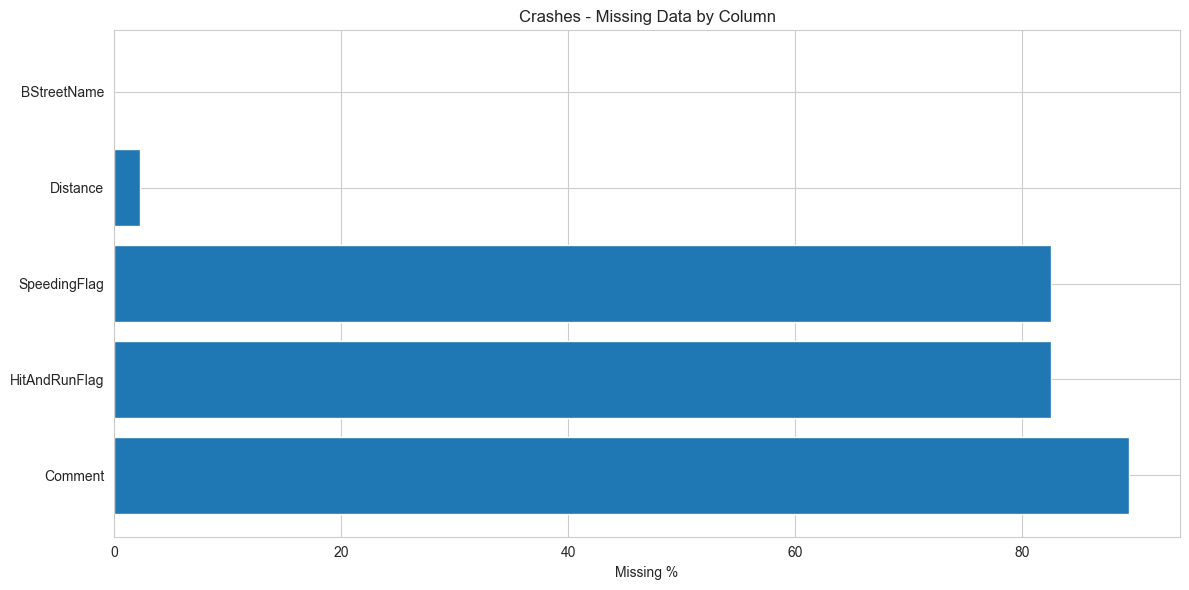

In [22]:
if len(crash_missing) > 0:
    plt.figure(figsize=(12, max(6, len(crash_missing) * 0.3)))
    plt.barh(crash_missing['column'], crash_missing['missing_pct'])
    plt.xlabel('Missing %')
    plt.title('Crashes - Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values in crashes dataset")

### 4.2 Vehicles Missing Values

In [23]:
vehicle_missing = pd.DataFrame({
    'column': vehicles.columns,
    'missing_count': vehicles.isnull().sum().values,
    'missing_pct': (vehicles.isnull().sum().values / len(vehicles) * 100)
}).sort_values('missing_pct', ascending=False)

vehicle_missing = vehicle_missing[vehicle_missing['missing_count'] > 0]

print("=" * 80)
print("VEHICLES - MISSING VALUES")
print("=" * 80)
print(f"\nTotal columns: {len(vehicles.columns)}")
print(f"Columns with missing data: {len(vehicle_missing)}")
print(f"\n{vehicle_missing.to_string(index=False)}")

VEHICLES - MISSING VALUES

Total columns: 27
Columns with missing data: 15

                 column  missing_count  missing_pct
                   Race         140203    91.797343
   VehicleMakeModelType         135502    88.719382
           PartySubType         133629    87.493043
        TrailerAttached         133629    87.493043
          MinorInjuries         123893    81.118437
         SevereInjuries         123884    81.112544
       ModerateInjuries         123884    81.112544
          FatalInjuries         123880    81.109925
        SafetyEquipment         123860    81.096830
       InattentionCodes         123860    81.096830
  PossibleTransientFlag         123860    81.096830
SafetyEquipmentCategory         123860    81.096830
                  Speed         101961    66.758549
                    Sex          41113    26.918569
          VehicleDamage           4595     3.008558


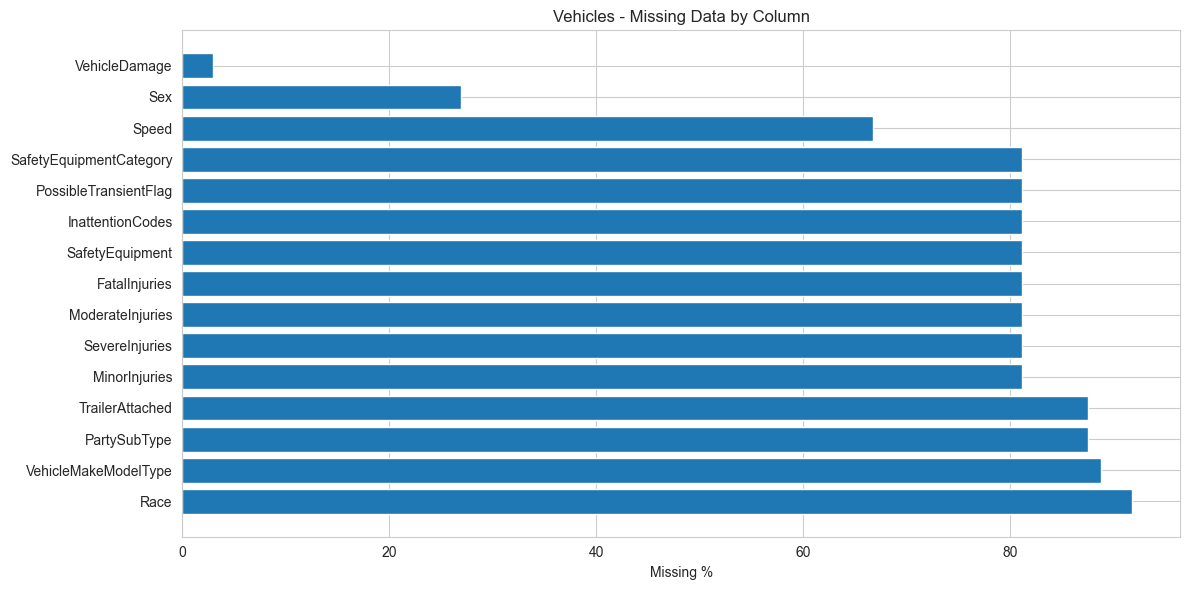

In [24]:
if len(vehicle_missing) > 0:
    plt.figure(figsize=(12, max(6, len(vehicle_missing) * 0.3)))
    plt.barh(vehicle_missing['column'], vehicle_missing['missing_pct'])
    plt.xlabel('Missing %')
    plt.title('Vehicles - Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values in vehicles dataset")

### 4.3 Missing Data Heatmap (Sample)

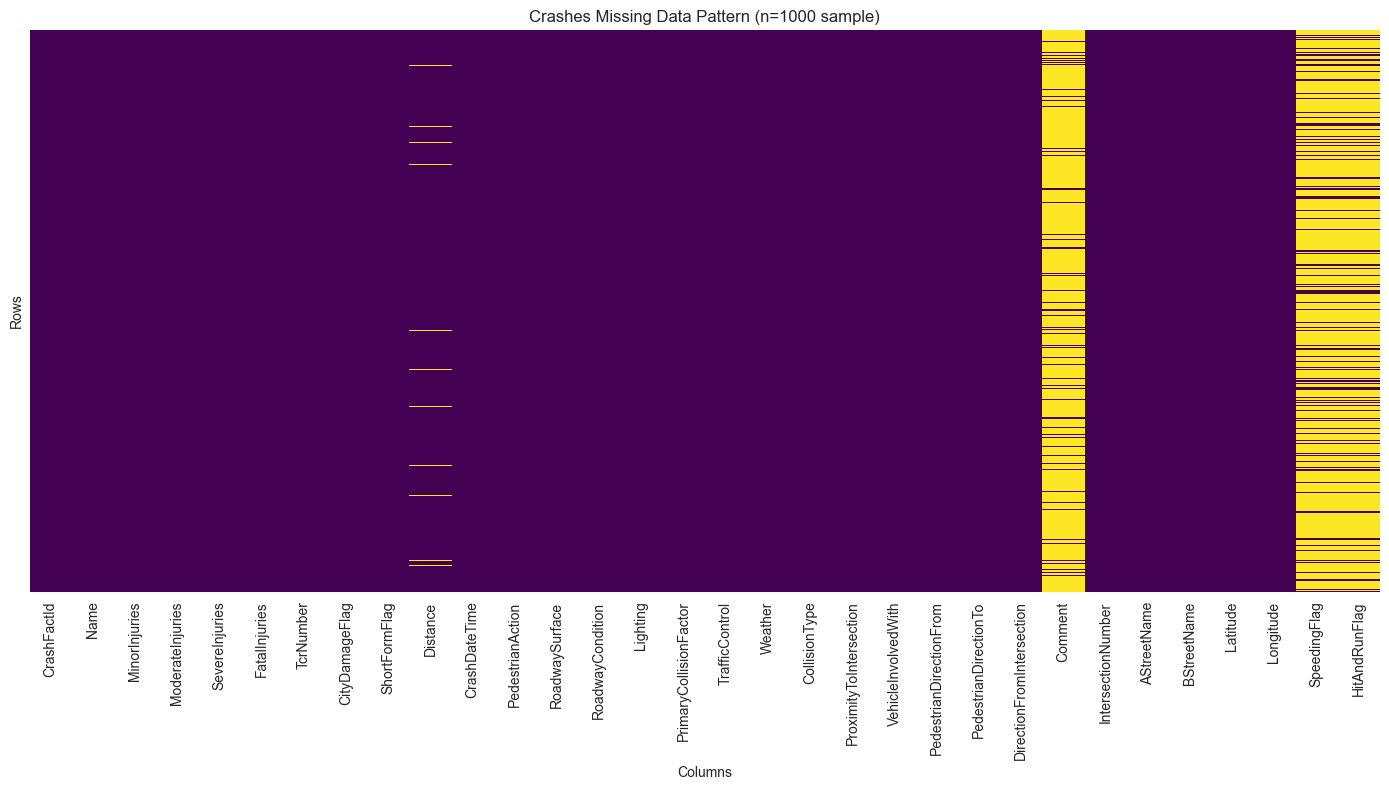

In [25]:
sample_size = min(1000, len(crashes))
crashes_sample = crashes.sample(n=sample_size, random_state=42)

plt.figure(figsize=(14, 8))
sns.heatmap(crashes_sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title(f'Crashes Missing Data Pattern (n={sample_size} sample)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Duplicate Detection

### 5.1 Crashes Duplicates

In [26]:
print("=" * 80)
print("CRASHES - DUPLICATE DETECTION")
print("=" * 80)

exact_dupes = crashes.duplicated().sum()
print(f"\nExact duplicate rows: {exact_dupes}")

if 'Name' in crashes.columns:
    name_dupes = crashes['Name'].duplicated().sum()
    print(f"Duplicate crash IDs (Name): {name_dupes}")
    
    if name_dupes > 0:
        print("\n⚠️  Sample duplicate crash IDs:")
        dup_names = crashes[crashes['Name'].duplicated(keep=False)]['Name'].unique()[:5]
        for name in dup_names:
            print(f"  - {name}: {(crashes['Name'] == name).sum()} occurrences")

if 'CrashFactId' in crashes.columns:
    factid_dupes = crashes['CrashFactId'].duplicated().sum()
    print(f"Duplicate CrashFactId: {factid_dupes}")

CRASHES - DUPLICATE DETECTION

Exact duplicate rows: 0
Duplicate crash IDs (Name): 0
Duplicate CrashFactId: 0


### 5.2 Vehicles Duplicates

In [27]:
print("=" * 80)
print("VEHICLES - DUPLICATE DETECTION")
print("=" * 80)

exact_dupes_v = vehicles.duplicated().sum()
print(f"\nExact duplicate rows: {exact_dupes_v}")

if 'Name' in vehicles.columns:
    name_dupes_v = vehicles['Name'].duplicated().sum()
    print(f"Duplicate vehicle IDs (Name): {name_dupes_v}")
    
    if name_dupes_v > 0:
        print("\n⚠️  Sample duplicate vehicle IDs:")
        dup_names_v = vehicles[vehicles['Name'].duplicated(keep=False)]['Name'].unique()[:5]
        for name in dup_names_v:
            print(f"  - {name}: {(vehicles['Name'] == name).sum()} occurrences")

if 'CrashName' in vehicles.columns:
    crash_name_counts = vehicles['CrashName'].value_counts()
    print(f"\nCrashes with multiple vehicles: {(crash_name_counts > 1).sum()}")
    print(f"Max vehicles per crash: {crash_name_counts.max()}")
    print(f"Avg vehicles per crash: {crash_name_counts.mean():.2f}")

VEHICLES - DUPLICATE DETECTION

Exact duplicate rows: 0
Duplicate vehicle IDs (Name): 0

Crashes with multiple vehicles: 65899
Max vehicles per crash: 14
Avg vehicles per crash: 2.06


## 6. Data Type Fixes

Convert columns to appropriate types.

### 6.1 Parse Datetime

In [28]:
if 'CrashDateTime' in crashes.columns:
    print("Converting CrashDateTime to datetime...")
    crashes['CrashDateTime'] = pd.to_datetime(crashes['CrashDateTime'], errors='coerce')
    
    crashes['crash_year'] = crashes['CrashDateTime'].dt.year
    crashes['crash_month'] = crashes['CrashDateTime'].dt.month
    crashes['crash_day'] = crashes['CrashDateTime'].dt.day
    crashes['crash_hour'] = crashes['CrashDateTime'].dt.hour
    crashes['crash_dayofweek'] = crashes['CrashDateTime'].dt.dayofweek
    crashes['crash_date'] = crashes['CrashDateTime'].dt.date
    
    print(f"✓ Parsed CrashDateTime")
    print(f"  Date range: {crashes['CrashDateTime'].min()} to {crashes['CrashDateTime'].max()}")
    print(f"  Invalid dates: {crashes['CrashDateTime'].isnull().sum()}")

Converting CrashDateTime to datetime...
✓ Parsed CrashDateTime
  Date range: 2011-01-01 00:09:00 to 2024-11-24 22:34:00
  Invalid dates: 0


### 6.2 Convert Boolean Columns

In [29]:
bool_cols_crashes = ['CityDamageFlag', 'ShortFormFlag', 'SpeedingFlag', 'HitAndRunFlag']
bool_cols_vehicles = ['PossibleTransientFlag', 'TrailerAttached']

for col in bool_cols_crashes:
    if col in crashes.columns:
        crashes[col] = crashes[col].map({'True': True, 'False': False, True: True, False: False})
        print(f"✓ Converted {col} to boolean")

for col in bool_cols_vehicles:
    if col in vehicles.columns:
        vehicles[col] = vehicles[col].map({'True': True, 'False': False, True: True, False: False})
        print(f"✓ Converted {col} to boolean")

✓ Converted CityDamageFlag to boolean
✓ Converted ShortFormFlag to boolean
✓ Converted SpeedingFlag to boolean
✓ Converted HitAndRunFlag to boolean
✓ Converted PossibleTransientFlag to boolean
✓ Converted TrailerAttached to boolean


### 6.3 Convert Numeric Columns

In [30]:
numeric_cols_crashes = ['MinorInjuries', 'ModerateInjuries', 'SevereInjuries', 'FatalInjuries', 
                        'Distance', 'IntersectionNumber', 'Latitude', 'Longitude']

for col in numeric_cols_crashes:
    if col in crashes.columns:
        crashes[col] = pd.to_numeric(crashes[col], errors='coerce')

numeric_cols_vehicles = ['Age', 'Speed', 'VehicleCount', 'FatalInjuries', 'SevereInjuries', 
                         'ModerateInjuries', 'MinorInjuries']

for col in numeric_cols_vehicles:
    if col in vehicles.columns:
        vehicles[col] = pd.to_numeric(vehicles[col], errors='coerce')

print("✓ Converted numeric columns")

✓ Converted numeric columns


### 6.4 Convert Categorical Columns

In [31]:
categorical_cols_crashes = ['PedestrianAction', 'RoadwaySurface', 'RoadwayCondition', 'Lighting',
                            'PrimaryCollisionFactor', 'TrafficControl', 'Weather', 'CollisionType',
                            'ProximityToIntersection', 'VehicleInvolvedWith', 'DirectionFromIntersection']

for col in categorical_cols_crashes:
    if col in crashes.columns:
        crashes[col] = crashes[col].astype('category')

categorical_cols_vehicles = ['Sex', 'PartyCategory', 'Sobriety', 'VehicleDirection', 
                             'MovementPrecedingCollision', 'PartyType', 'OtherAssociatedFactor',
                             'VehicleDamage', 'PartySubType', 'Race', 'SafetyEquipment']

for col in categorical_cols_vehicles:
    if col in vehicles.columns:
        vehicles[col] = vehicles[col].astype('category')

print("✓ Converted categorical columns")

✓ Converted categorical columns


## 7. Foreign Key Validation

Check the relationship between crashes and vehicles before merging.

In [32]:
print("=" * 80)
print("FOREIGN KEY VALIDATION")
print("=" * 80)

crash_ids = set(crashes['Name'].dropna())
vehicle_crash_refs = set(vehicles['CrashName'].dropna())

print(f"\nUnique crash IDs in crashes table: {len(crash_ids)}")
print(f"Unique crash IDs referenced in vehicles table: {len(vehicle_crash_refs)}")

orphan_vehicles = vehicle_crash_refs - crash_ids
crashes_without_vehicles = crash_ids - vehicle_crash_refs

print(f"\nOrphan vehicles (no matching crash): {len(orphan_vehicles)}")
if len(orphan_vehicles) > 0:
    print(f"  Sample: {list(orphan_vehicles)[:5]}")

print(f"\nCrashes without vehicles: {len(crashes_without_vehicles)}")
if len(crashes_without_vehicles) > 0:
    print(f"  Sample: {list(crashes_without_vehicles)[:5]}")

print(f"\nVehicles per crash distribution:")
vehicles_per_crash = vehicles['CrashName'].value_counts()
print(vehicles_per_crash.describe())

FOREIGN KEY VALIDATION

Unique crash IDs in crashes table: 74195
Unique crash IDs referenced in vehicles table: 74179

Orphan vehicles (no matching crash): 0

Crashes without vehicles: 16
  Sample: ['CR-0000087703', 'CR-0000067587', 'CR-0000065357', 'CR-0000064061', 'CR-0000096484']

Vehicles per crash distribution:
count    74179.000000
mean         2.058952
std          0.631837
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         14.000000
Name: count, dtype: float64


## 8. Add Vehicle Sobreity to Crash

Create a unified dataset with one row per CRASH, including all crash-level information and max priority sobriety value from all vehicals involved.

In [33]:

priority = {
    'Not Applicable': 1,
    'Had Not Been Drinking': 2,
    'Had Been Drinking - Not Under Influence': 3,
    'Impairment Physcial': 4,
    'Sleepy/Fatigued': 5,
    'Had Been Drinking - Impairment Not Known': 6,
    'Had Been Drinking - Under Influence': 7,
    'Under Drug Influence': 8
}
vehicles['Priority'] = vehicles['Sobriety'].map(priority)

max_priority_per_crash = vehicles.groupby('CrashName')['Priority'].max()

priority_to_sobriety = {v: k for k, v in priority.items()}

crash_max_priority = crashes['Name'].map(max_priority_per_crash)
crashes_sobriety = crashes.copy()
crashes_sobriety['Sobriety'] = crash_max_priority.map(priority_to_sobriety)


crashes_sobriety['Sobriety'].fillna('Impairment Not Known', inplace=True)

0                       Impairment Not Known
1                      Had Not Been Drinking
2                      Had Not Been Drinking
3        Had Been Drinking - Under Influence
4                      Had Not Been Drinking
                        ...                 
74190                  Had Not Been Drinking
74191                   Impairment Not Known
74192                         Not Applicable
74193                   Under Drug Influence
74194                   Impairment Not Known
Name: Sobriety, Length: 74195, dtype: str

In [34]:
crashes_sobriety.head(3)

,CrashFactId,Name,MinorInjuries,ModerateInjuries,SevereInjuries,FatalInjuries,TcrNumber,CityDamageFlag,ShortFormFlag,Distance,CrashDateTime,PedestrianAction,RoadwaySurface,RoadwayCondition,Lighting,PrimaryCollisionFactor,TrafficControl,Weather,CollisionType,ProximityToIntersection,VehicleInvolvedWith,PedestrianDirectionFrom,PedestrianDirectionTo,DirectionFromIntersection,Comment,IntersectionNumber,AStreetName,BStreetName,Latitude,Longitude,SpeedingFlag,HitAndRunFlag,crash_year,crash_month,crash_day,crash_hour,crash_dayofweek,crash_date,Sobriety
0,591079,CR-0000071607,0,0,0,0,18-073-0962,True,False,228.0,2018-03-14 23:17:00,No Pedestrians Involved,Wet,No Unusual Conditions,Dark - Street Light,Violation Driver 1,No Controls Present/Factor,Clear,Hit Object,Non-Related,Fixed Object,Not Applicable,Not Applicable,East Of,V1 HIT CEMENT GUARD RAIL,116654,BLOSSOM HILL RD,MONTEREY RD,37.255036,-121.801352,NaN,NaN,2018,3,14,23,2,2018-03-14,NaN
1,591080,CR-0000071780,0,0,0,0,18-060-0123,True,False,148.0,2018-03-01 07:30:00,No Pedestrians Involved,Wet,No Unusual Conditions,Daylight,Violation Driver 1,No Controls Present/Factor,Rain,Hit Object,Non-Related,Fixed Object,Not Applicable,Not Applicable,West Of,v1 hit city pole,20349,BLOSSOM HILL RD,PLAYA DEL REY,37.250315,-121.852909,NaN,NaN,2018,3,1,7,3,2018-03-01,Had Not Been Drinking
2,591081,CR-0000060418,0,0,0,0,16-033-0204,False,False,1583.0,2016-02-02 09:02:00,No Pedestrians Involved,Wet,No Unusual Conditions,Daylight,Violation Driver 1,No Controls Present/Factor,Rain,Overturned,Non-Related,Fixed Object,Not Applicable,Not Applicable,South Of,NaN,137543,HAWKSTONE WY,SILVER CREEK VALLEY RD,37.276644,-121.779375,NaN,NaN,2016,2,2,9,1,2016-02-02,Had Not Been Drinking


## 9. Derive Target Variable

Create `injury_severity` (0-4 scale) from injury columns.

In [35]:
def derive_severity(row):
    """
    Derive injury severity from crash-level injury counts.
    0 = No injury
    1 = Minor injury
    2 = Moderate injury
    3 = Severe injury
    4 = Fatal
    """
    if pd.notna(row['FatalInjuries']) and row['FatalInjuries'] > 0:
        return 4
    elif pd.notna(row['SevereInjuries']) and row['SevereInjuries'] > 0:
        return 3
    elif pd.notna(row['ModerateInjuries']) and row['ModerateInjuries'] > 0:
        return 2
    elif pd.notna(row['MinorInjuries']) and row['MinorInjuries'] > 0:
        return 1
    else:
        return 0

crashes_sobriety['injury_severity'] = crashes_sobriety.apply(derive_severity, axis=1)

print("=" * 80)
print("TARGET VARIABLE: injury_severity")
print("=" * 80)
print(f"\n{crashes_sobriety['injury_severity'].value_counts().sort_index()}")
print(f"\nPercentage distribution:")
print(crashes_sobriety['injury_severity'].value_counts(normalize=True).sort_index() * 100)

TARGET VARIABLE: injury_severity

injury_severity
0    41579
1    20011
2     9658
3     2293
4      654
Name: count, dtype: int64

Percentage distribution:
injury_severity
0    56.040164
1    26.970820
2    13.017050
3     3.090505
4     0.881461
Name: proportion, dtype: float64


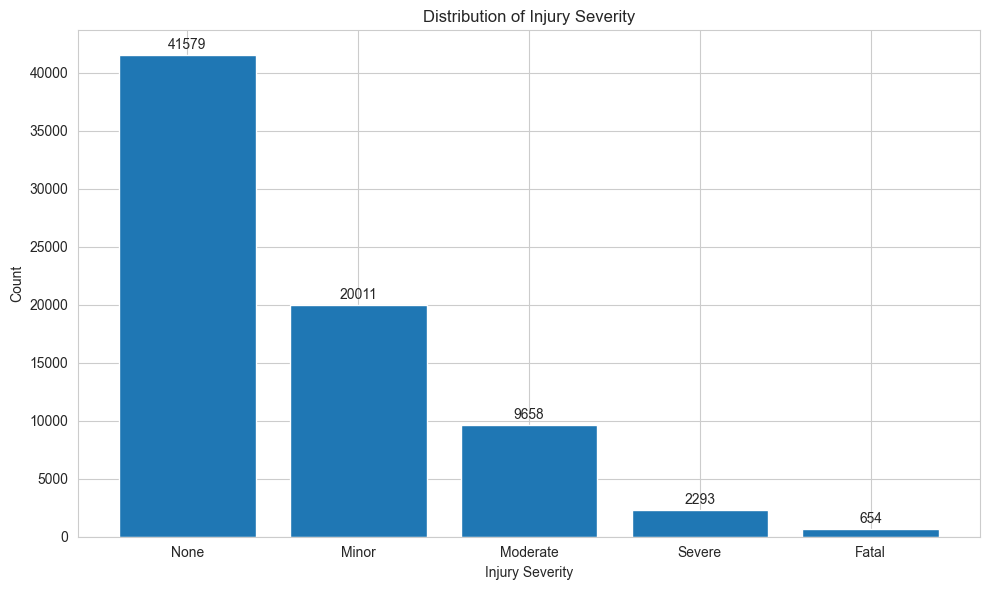

In [36]:
plt.figure(figsize=(10, 6))
severity_counts = crashes_sobriety['injury_severity'].value_counts().sort_index()
plt.bar(severity_counts.index, severity_counts.values)
plt.xlabel('Injury Severity')
plt.ylabel('Count')
plt.title('Distribution of Injury Severity')
plt.xticks([0, 1, 2, 3, 4], ['None', 'Minor', 'Moderate', 'Severe', 'Fatal'])
for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.tight_layout()
plt.show()

## 10. Data Quality Summary

In [39]:
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

print(f"\nFinal merged dataset: {crashes_sobriety.shape}")
print(f"Total features: {crashes_sobriety.shape[1]}")
print(f"Total records: {crashes_sobriety.shape[0]:,}")

print(f"\nDate range: {crashes_sobriety['CrashDateTime'].min()} to {crashes_sobriety['CrashDateTime'].max()}")
print(f"Unique crashes: {crashes_sobriety['Name'].nunique():,}")
#print(f"Unique vehicles: {crashes_sobriety['Name_vehicle'].nunique():,}")

print(f"\nMissing values:")
missing_summary = crashes_sobriety.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(f"  Columns with missing data: {len(missing_summary)}")
    print(f"  Worst offender: {missing_summary.index[0]} ({missing_summary.iloc[0]:,} nulls, {missing_summary.iloc[0]/len(crashes_sobriety)*100:.1f}%)")
else:
    print("  ✓ No missing values")

print(f"\nTarget variable (injury_severity):")
print(f"  Classes: {crashes_sobriety['injury_severity'].nunique()}")
print(f"  Most common: {crashes_sobriety['injury_severity'].mode()[0]} ({crashes_sobriety['injury_severity'].value_counts().iloc[0]:,} records)")
print(f"  Least common: {crashes_sobriety['injury_severity'].value_counts().index[-1]} ({crashes_sobriety['injury_severity'].value_counts().iloc[-1]:,} records)")
print(f"  Class imbalance ratio: {crashes_sobriety['injury_severity'].value_counts().iloc[0] / crashes_sobriety['injury_severity'].value_counts().iloc[-1]:.1f}:1")

DATA QUALITY SUMMARY

Final merged dataset: (74195, 40)
Total features: 40
Total records: 74,195

Date range: 2011-01-01 00:09:00 to 2024-11-24 22:34:00
Unique crashes: 74,195

Missing values:
  Columns with missing data: 6
  Worst offender: Comment (66,335 nulls, 89.4%)

Target variable (injury_severity):
  Classes: 5
  Most common: 0 (41,579 records)
  Least common: 4 (654 records)
  Class imbalance ratio: 63.6:1


## 11. Export Cleaned Data

In [ ]:
output_path = DATA_PROCESSED / 'crashes+.csv'
print(f"Exporting to {output_path}...")
crashes_sobriety.to_csv(output_path, index=False)
print(f"✓ Saved {len(crashes_sobriety):,} records to {output_path}")
print(f"  File size: {output_path.stat().st_size / 1024**2:.2f} MB")

Exporting to ..\data\processed\crashes+_data.csv...
✓ Saved 74,195 records to ..\data\processed\crashes+_data.csv
  File size: 25.64 MB


In [38]:
crashes_output = DATA_PROCESSED / 'crashes_clean.csv'
vehicles_output = DATA_PROCESSED / 'vehicles_clean.csv'

print(f"\nExporting individual cleaned datasets...")
crashes.to_csv(crashes_output, index=False)
vehicles.to_csv(vehicles_output, index=False)
print(f"✓ Saved crashes to {crashes_output}")
print(f"✓ Saved vehicles to {vehicles_output}")


Exporting individual cleaned datasets...
✓ Saved crashes to ..\data\processed\crashes_clean.csv
✓ Saved vehicles to ..\data\processed\vehicles_clean.csv


## 12. Crashes with Soberity

## 13. Key Findings & Next Steps

### Key Findings
1. **Dataset size**: ~74K crashes, ~153K vehicles, ~74K records
2. **Time span**: 2011-2024
3. **Schema differences**: 2022+ data includes `SpeedingFlag` and `HitAndRunFlag`
4. **Missing data**: Check the missing values analysis above for columns that need attention
5. **Class imbalance**: Injury severity is heavily skewed toward no-injury crashes
6. **Foreign key integrity**: Validated crash-vehicle relationship

### Next Steps (Notebook 02 - EDA)
1. Temporal analysis (crashes over time, by hour/day/month)
2. Geospatial analysis (hotspot mapping)
3. Feature distributions and relationships
4. Correlation analysis
5. Severity vs. conditions (weather, lighting, road type)
6. Identify features for engineering